# Phase 4: Pemodelan RFR & Validasi Spasial Bebas Leakage (Group-LOSOCV)

Notebook ini berfokus pada:
1. Membagi stasiun ke dalam **Grid Group** berdasarkan kesamaan grid model CAMS (Open-Meteo) untuk mengatasi *Spatial Target Leakage*.
2. Melakukan evaluasi model menggunakan metode **Group-LOSOCV (Grouped Leave-One-Station-Out Cross-Validation)** yang mengeluarkan seluruh stasiun dalam satu grid saat pengujian.
3. Melatih model Random Forest Regressor (RFR) final pada seluruh data dan menyimpan model terlatih.
4. Menganalisis dan memvisualisasikan tingkat kepentingan fitur (*Feature Importance*).

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib

# Set style visualisasi premium
sns.set_theme(style="ticks")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100

# 1. Load model-ready dataset hasil feature engineering
data_path = os.path.join('data', 'model_ready_data.csv')
df = pd.read_csv(data_path)
df['waktu'] = pd.to_datetime(df['waktu'])

# 2. Definisikan CAMS Grid Group untuk mengatasi Isu 1 (Spatial Target Leakage)
def get_grid_group(stasiun):
    if stasiun in ['Menteng', 'Slipi', 'Kelapa Gading Indah']:
        return 'Group_A'  # Grid CAMS Utara-Pusat-Barat
    elif stasiun in ['Jagakarsa', 'Jatinegara']:
        return 'Group_B'  # Grid CAMS Selatan-Timur
    return 'Unknown'

df['grid_group'] = df['stasiun'].apply(get_grid_group)

print("Dataset Berhasil Dimuat & Dikelompokkan berdasarkan Grid CAMS:")
print(f"Total baris data: {len(df)}")
print(df[['stasiun', 'grid_group', 'latitude', 'longitude']].drop_duplicates().to_string(index=False))

Dataset Berhasil Dimuat & Dikelompokkan berdasarkan Grid CAMS:
Total baris data: 131640
            stasiun grid_group  latitude  longitude
          Jagakarsa    Group_B   -6.3341   106.8214
         Jatinegara    Group_B   -6.2322   106.8811
Kelapa Gading Indah    Group_A   -6.1673   106.9052
            Menteng    Group_A   -6.1994   106.8392
              Slipi    Group_A   -6.1950   106.8025


## Leave-One-Station-Out Cross-Validation (Group - LOSOCV) Loop

In [3]:
# =================================================================
# CELL EVALUASI: GROUP-LOSOCV (RFR TUNED + COORDS + WEATHER LAGS)
# =================================================================

# 1. Definisikan prediktor final lengkap DENGAN koordinat dan lag cuaca
features_with_coords_lags = [
    'latitude', 'longitude',                             # Sertakan koordinat
    'temperature_2m', 'apparent_temperature', 'relative_humidity_2m',
    'dew_point_2m', 'precipitation', 'rain', 'surface_pressure',
    'cloud_cover_total', 'u_wind', 'v_wind', 'jam', 'bulan',
    'hari_dalam_minggu', 'is_weekend', 'AOD',
    'v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1' # Fitur lag cuaca
]
target = 'PM2.5'

# Pastikan data lag sudah bersih dan terurut
df_lag = df.sort_values(by=['stasiun', 'waktu']).reset_index(drop=True)
df_lag['v_wind_lag1'] = df_lag.groupby('stasiun')['v_wind'].shift(1)
df_lag['u_wind_lag1'] = df_lag.groupby('stasiun')['u_wind'].shift(1)
df_lag['temp_lag1'] = df_lag.groupby('stasiun')['temperature_2m'].shift(1)
df_lag['rh_lag1'] = df_lag.groupby('stasiun')['relative_humidity_2m'].shift(1)
df_lag = df_lag.dropna(subset=['v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1']).reset_index(drop=True)

stasiun_list = df_lag['stasiun'].unique()
results_rfr_tuned = []

print("=================================================================")
print("MENJALANKAN GROUP-LOSOCV (RFR TUNED + COORDS + WEATHER LAGS)")
print("=================================================================")

for test_station in stasiun_list:
    test_group = df_lag[df_lag['stasiun'] == test_station]['grid_group'].values[0]

    # Split train/test dengan isolasi grid group
    train_df = df_lag[df_lag['grid_group'] != test_group]
    test_df = df_lag[df_lag['stasiun'] == test_station]

    X_train = train_df[features_with_coords_lags]
    y_train = train_df[target]
    X_test = test_df[features_with_coords_lags]
    y_test = test_df[target]

    # Train RFR menggunakan parameter terbaik hasil tuning
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        max_features='log2',
        min_samples_split=2,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results_rfr_tuned.append({
        'stasiun_uji': test_station,
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae
    })
    print(f"Stasiun Uji: {test_station:<20} | R2 = {r2:.6f} | RMSE = {rmse:.6f} | MAE = {mae:.6f}")

df_results_rfr = pd.DataFrame(results_rfr_tuned)
global_r2_rfr = df_results_rfr['R2'].mean()
global_rmse_rfr = df_results_rfr['RMSE'].mean()
global_mae_rfr = df_results_rfr['MAE'].mean()

print("=================================================================")
print("RINGKASAN METRIK GROUP-LOSOCV (RFR TUNED + COORDS + WEATHER LAGS)")
print("=================================================================")
print(df_results_rfr.to_string(index=False))
print("-----------------------------------------------------------------")
print(f"RATA-RATA GLOBAL TEROPTIMASI: R2 = {global_r2_rfr:.4f} | RMSE = {global_rmse_rfr:.2f} µg/m³ | MAE = {global_mae_rfr:.2f} µg/m³")
print("=================================================================")

MENJALANKAN GROUP-LOSOCV (RFR TUNED + COORDS + WEATHER LAGS)
Stasiun Uji: Jagakarsa            | R2 = 0.196786 | RMSE = 31.402665 | MAE = 22.218998
Stasiun Uji: Jatinegara           | R2 = 0.413463 | RMSE = 26.834820 | MAE = 18.985210
Stasiun Uji: Kelapa Gading Indah  | R2 = 0.119682 | RMSE = 26.449698 | MAE = 20.500793
Stasiun Uji: Menteng              | R2 = 0.169735 | RMSE = 25.686761 | MAE = 20.244760
Stasiun Uji: Slipi                | R2 = 0.042018 | RMSE = 27.591765 | MAE = 21.714805
RINGKASAN METRIK GROUP-LOSOCV (RFR TUNED + COORDS + WEATHER LAGS)
        stasiun_uji       R2      RMSE       MAE
          Jagakarsa 0.196786 31.402665 22.218998
         Jatinegara 0.413463 26.834820 18.985210
Kelapa Gading Indah 0.119682 26.449698 20.500793
            Menteng 0.169735 25.686761 20.244760
              Slipi 0.042018 27.591765 21.714805
-----------------------------------------------------------------
RATA-RATA GLOBAL TEROPTIMASI: R2 = 0.1883 | RMSE = 27.59 µg/m³ | MAE = 20.73 µ

## Pelatihan Akhir (Final Training) & Feature Importance

Melatih model RFR final teroptimasi (Dengan Koordinat + Lags)...
✓ Model final RFR + Koordinat + Lag cuaca berhasil disimpan di: data\pm25_rfr_model.pkl

Tabel Feature Importance Final (Tuned RFR Model + Coords + Lags):
               Fitur  Importance
         v_wind_lag1    0.142389
              v_wind    0.132107
               bulan    0.112305
                 jam    0.090043
            latitude    0.059456
      temperature_2m    0.048322
           temp_lag1    0.044792
relative_humidity_2m    0.044487
    surface_pressure    0.043445
             rh_lag1    0.038098
         u_wind_lag1    0.037284
              u_wind    0.035615
apparent_temperature    0.035255
        dew_point_2m    0.030970
   cloud_cover_total    0.028928
   hari_dalam_minggu    0.020364
       precipitation    0.019757
                rain    0.017083
           longitude    0.011953
          is_weekend    0.004559
                 AOD    0.002786


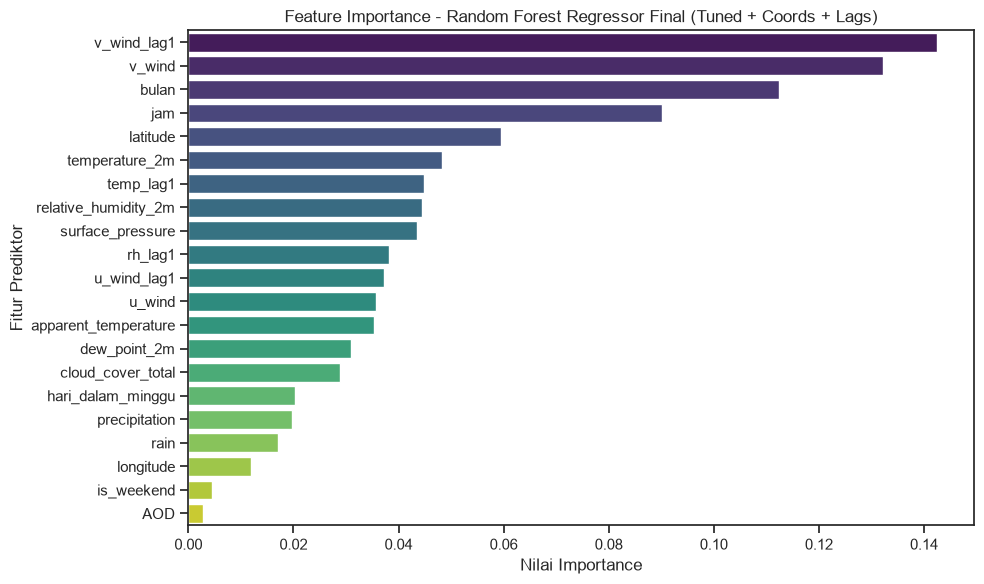

✓ Grafik Feature Importance teroptimasi disimpan di: results\images\feature_importance_rfr.png


In [4]:
# =================================================================
# CELL FINAL: MELATIH MODEL RFR DENGAN HYPERPARAMETER TEROPTIMAL + COORDS + LAGS
# =================================================================
from sklearn.ensemble import RandomForestRegressor
import joblib

# 1. Pastikan data terurut berdasarkan stasiun dan waktu
df_lag = df.sort_values(by=['stasiun', 'waktu']).reset_index(drop=True)

# 2. Buat fitur lag cuaca 1 jam yang lalu
df_lag['v_wind_lag1'] = df_lag.groupby('stasiun')['v_wind'].shift(1)
df_lag['u_wind_lag1'] = df_lag.groupby('stasiun')['u_wind'].shift(1)
df_lag['temp_lag1'] = df_lag.groupby('stasiun')['temperature_2m'].shift(1)
df_lag['rh_lag1'] = df_lag.groupby('stasiun')['relative_humidity_2m'].shift(1)

# Hapus baris pertama setiap stasiun yang bernilai NaN hasil shifting
df_lag = df_lag.dropna(subset=['v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1']).reset_index(drop=True)

# 3. Definisikan prediktor final lengkap DENGAN koordinat dan lag cuaca
features_with_coords_lags = [
    'latitude', 'longitude',                             # Sertakan koordinat
    'temperature_2m', 'apparent_temperature', 'relative_humidity_2m',
    'dew_point_2m', 'precipitation', 'rain', 'surface_pressure',
    'cloud_cover_total', 'u_wind', 'v_wind', 'jam', 'bulan',
    'hari_dalam_minggu', 'is_weekend', 'AOD',
    'v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1' # Fitur lag cuaca
]
target = 'PM2.5'

# 4. Latih model final RFR pada SELURUH data stasiun menggunakan parameter terbaik GridSearch
X_final = df_lag[features_with_coords_lags]
y_final = df_lag[target]

print("Melatih model RFR final teroptimasi (Dengan Koordinat + Lags)...")
final_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    max_features='log2',
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_final, y_final)

# 5. Simpan model terlatih ke disk (.pkl)
model_output_path = os.path.join('data', 'pm25_rfr_model.pkl')
joblib.dump(final_model, model_output_path)
print(f"✓ Model final RFR + Koordinat + Lag cuaca berhasil disimpan di: {model_output_path}")

# 6. Hitung Feature Importance
importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1]

df_importance = pd.DataFrame({
    'Fitur': [features_with_coords_lags[i] for i in indices],
    'Importance': [importances[i] for i in indices]
})

print("\nTabel Feature Importance Final (Tuned RFR Model + Coords + Lags):")
print(df_importance.to_string(index=False))

# 7. Visualisasikan Feature Importance (Bebas dari Warning Seaborn)
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Fitur',
    data=df_importance,
    palette='viridis',
    hue='Fitur',          # Menghindari FutureWarning
    legend=False          # Menghindari FutureWarning
)
plt.title('Feature Importance - Random Forest Regressor Final (Tuned + Coords + Lags)')
plt.xlabel('Nilai Importance')
plt.ylabel('Fitur Prediktor')
plt.tight_layout()

# Simpan grafik feature importance terbaru
image_output_path = os.path.join('results', 'images', 'feature_importance_rfr.png')
os.makedirs(os.path.dirname(image_output_path), exist_ok=True)
plt.savefig(image_output_path, dpi=300)
plt.show()
print(f"✓ Grafik Feature Importance teroptimasi disimpan di: {image_output_path}")

## Metode Alternatif Extremely Randomized Trees

In [ ]:
# =================================================================
# CELL EVALUASI: GROUP-LOSOCV (EXTRA TREES TUNED + COORDS + LAGS)
# =================================================================
from sklearn.ensemble import ExtraTreesRegressor

# 1. Definisikan prediktor final LENGKAP dengan koordinat dan lag cuaca
features_with_coords_lags = [
    'latitude', 'longitude',                             # Sertakan koordinat untuk sinkronisasi
    'temperature_2m', 'apparent_temperature', 'relative_humidity_2m',
    'dew_point_2m', 'precipitation', 'rain', 'surface_pressure',
    'cloud_cover_total', 'u_wind', 'v_wind', 'jam', 'bulan',
    'hari_dalam_minggu', 'is_weekend', 'AOD',
    'v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1'
]
target = 'PM2.5'

# Pastikan data lag sudah bersih
df_lag = df.sort_values(by=['stasiun', 'waktu']).reset_index(drop=True)
df_lag['v_wind_lag1'] = df_lag.groupby('stasiun')['v_wind'].shift(1)
df_lag['u_wind_lag1'] = df_lag.groupby('stasiun')['u_wind'].shift(1)
df_lag['temp_lag1'] = df_lag.groupby('stasiun')['temperature_2m'].shift(1)
df_lag['rh_lag1'] = df_lag.groupby('stasiun')['relative_humidity_2m'].shift(1)
df_lag = df_lag.dropna(subset=['v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1']).reset_index(drop=True)

stasiun_list = df_lag['stasiun'].unique()
results_et_tuned = []

print("=================================================================")
print("MENJALANKAN GROUP-LOSOCV (EXTRA TREES TEROPTIMAL + COORDS + LAGS)")
print("=================================================================")

for test_station in stasiun_list:
    test_group = df_lag[df_lag['stasiun'] == test_station]['grid_group'].values[0]

    # Split train/test dengan isolasi grid group
    train_df = df_lag[df_lag['grid_group'] != test_group]
    test_df = df_lag[df_lag['stasiun'] == test_station]

    X_train = train_df[features_with_coords_lags]
    y_train = train_df[target]
    X_test = test_df[features_with_coords_lags]
    y_test = test_df[target]

    # Inisialisasi Extra Trees Regressor dengan parameter terbaik hasil GridSearchCV
    model = ExtraTreesRegressor(
        n_estimators=200,
        max_depth=None,
        max_features=None,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Hitung metrik
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results_et_tuned.append({
        'stasiun_uji': test_station,
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae
    })
    print(f"Stasiun Uji: {test_station:<20} | R2 = {r2:.6f} | RMSE = {rmse:.6f} | MAE = {mae:.6f}")

# Tampilkan ringkasan hasil akhir
df_results_et = pd.DataFrame(results_et_tuned)
global_r2_et = df_results_et['R2'].mean()
global_rmse_et = df_results_et['RMSE'].mean()
global_mae_et = df_results_et['MAE'].mean()

print("=================================================================")
print("RINGKASAN AKHIR GROUP-LOSOCV (EXTRA TREES TUNED + COORDS + LAGS)")
print("=================================================================")
print(df_results_et.to_string(index=False))
print("-----------------------------------------------------------------")
print(f"RATA-RATA GLOBAL TEROPTIMASI: R2 = {global_r2_et:.4f} | RMSE = {global_rmse_et:.2f} µg/m³ | MAE = {global_mae_et:.2f} µg/m³")
print("=================================================================")

MENJALANKAN GROUP-LOSOCV (EXTRA TREES TEROPTIMAL + COORDS + LAGS)
Stasiun Uji: Jagakarsa            | R2 = 0.236819 | RMSE = 30.610091 | MAE = 21.699454


In [ ]:
# =================================================================
# CELL FINAL: MELATIH MODEL EXTRA TREES DENGAN KOORDINAT + LAGS
# =================================================================
from sklearn.ensemble import ExtraTreesRegressor
import joblib

# 1. Pastikan data terurut berdasarkan stasiun dan waktu
df_lag = df.sort_values(by=['stasiun', 'waktu']).reset_index(drop=True)

# 2. Buat fitur lag cuaca 1 jam yang lalu
df_lag['v_wind_lag1'] = df_lag.groupby('stasiun')['v_wind'].shift(1)
df_lag['u_wind_lag1'] = df_lag.groupby('stasiun')['u_wind'].shift(1)
df_lag['temp_lag1'] = df_lag.groupby('stasiun')['temperature_2m'].shift(1)
df_lag['rh_lag1'] = df_lag.groupby('stasiun')['relative_humidity_2m'].shift(1)

# Hapus baris pertama setiap stasiun yang bernilai NaN hasil shifting
df_lag = df_lag.dropna(subset=['v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1']).reset_index(drop=True)

# 3. Definisikan prediktor final lengkap DENGAN koordinat dan lag cuaca
features_with_coords_lags = [
    'latitude', 'longitude',                             # Masukkan koordinat
    'temperature_2m', 'apparent_temperature', 'relative_humidity_2m',
    'dew_point_2m', 'precipitation', 'rain', 'surface_pressure',
    'cloud_cover_total', 'u_wind', 'v_wind', 'jam', 'bulan',
    'hari_dalam_minggu', 'is_weekend', 'AOD',
    'v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1' # Fitur lag cuaca
]
target = 'PM2.5'

# 4. Latih model final EXTRA TREES pada SELURUH data stasiun menggunakan parameter terbaik
X_final = df_lag[features_with_coords_lags]
y_final = df_lag[target]

print("Melatih model Extra Trees final (Dengan Koordinat + Lags)...")
final_model = ExtraTreesRegressor(
    n_estimators=200,
    max_depth=None,
    max_features=None,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_final, y_final)

# 5. Simpan model terlatih ke disk (.pkl)
etr_output_path = os.path.join('data', 'pm25_etr_model.pkl')
joblib.dump(final_model, etr_output_path)
print(f"✓ Model final Extra Trees teroptimasi berhasil disimpan di: {etr_output_path}")

# 6. Hitung Feature Importance
importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1]

df_importance = pd.DataFrame({
    'Fitur': [features_with_coords_lags[i] for i in indices],
    'Importance': [importances[i] for i in indices]
})

print("\nTabel Feature Importance Final (Tuned Extra Trees + Lags):")
print(df_importance.to_string(index=False))

# 7. Visualisasikan Feature Importance (Bebas dari Warning Seaborn)
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Fitur',
    data=df_importance,
    palette='viridis',
    hue='Fitur',          # Menghindari FutureWarning
    legend=False          # Menghindari FutureWarning
)
plt.title('Feature Importance - Extra Trees Final (Tuned + Lags)')
plt.xlabel('Nilai Importance')
plt.ylabel('Fitur Prediktor')
plt.tight_layout()

# Simpan grafik feature importance terbaru
image_output_path = os.path.join('results', 'images', 'feature_importance_etr.png')
os.makedirs(os.path.dirname(image_output_path), exist_ok=True)
plt.savefig(image_output_path, dpi=300)
plt.show()
print(f"✓ Grafik Feature Importance teroptimasi disimpan di: {image_output_path}")

NameError: name 'df' is not defined